In [3]:
"""
OTSG Modeling Project: Once-Through Steam Generator Simulation
A multi-phase model integrating TESPy, CoolProp, and custom moving-boundary methods
"""

import numpy as np
import CoolProp.CoolProp as CP
from scipy.integrate import solve_ivp
from dataclasses import dataclass
from typing import Tuple, Dict

# --- Parameters & Setup ---

@dataclass
class OTSGParameters:
    """Main parameters for the Once-Through Steam Generator"""
    primary_pressure: float = 15.5          # MPa
    primary_inlet_temp: float = 315.0       # °C
    primary_outlet_temp: float = 290.0      # °C
    primary_mass_flow: float = 1000.0       # kg/s
    
    secondary_pressure: float = 7.0         # MPa
    secondary_inlet_temp: float = 200.0     # °C
    secondary_outlet_temp: float = 280.0    # °C
    secondary_mass_flow: float = 150.0      # kg/s
    
    tube_length: float = 20.0               # meters
    tube_inner_diameter: float = 0.015      # meters
    tube_outer_diameter: float = 0.019      # meters
    number_of_tubes: int = 1000
    tube_thermal_conductivity: float = 16.0 # W/(m·K) (Inconel 690)
    
    primary_h_coeff: float = 30000.0        # W/(m²·K)
    secondary_h_coeff: float = 25000.0      # W/(m²·K)


class CoolPropThermo:
    """Wrapper for CoolProp thermodynamic property calculations"""
    
    @staticmethod
    def get_enthalpy(pressure: float, temperature: float) -> float:
        """Calculate enthalpy using CoolProp (Returns: kJ/kg)"""
        try:
            p_pa = pressure * 1e6
            T_K = temperature + 273.15
            h = CP.PropsSI('H', 'T', T_K, 'P', p_pa, 'Water')
            return h / 1000.0
        except Exception:
            return 1000.0 + 2.0 * temperature
    
    @staticmethod
    def get_temperature(pressure: float, enthalpy: float) -> float:
        """Calculate temperature from pressure and enthalpy (Returns: °C)"""
        try:
            p_pa = pressure * 1e6
            h_J = enthalpy * 1000.0
            T_K = CP.PropsSI('T', 'H', h_J, 'P', p_pa, 'Water')
            return T_K - 273.15
        except Exception:
            return (enthalpy - 1000.0) / 2.0
    
    @staticmethod
    def get_saturation_temperature(pressure: float) -> float:
        """Get saturation temperature at given pressure (Returns: °C)"""
        try:
            p_pa = pressure * 1e6
            T_sat_K = CP.PropsSI('T', 'Q', 0.5, 'P', p_pa, 'Water')
            return T_sat_K - 273.15
        except Exception:
            if pressure < 22.064:
                return 100.0 + 20.0 * np.log(pressure)
            return 374.0


# --- Network & Steady State ---

class TESPyStyleNetwork:
    """Simplified TESPy-style network for OTSG modeling"""
    
    def __init__(self, params: OTSGParameters):
        self.params = params
        self.thermo = CoolPropThermo()
        self.results = {}
        
    def solve_steady_state(self) -> Dict:
        """Solve the OTSG steady-state using simple energy balance"""
        Q_primary = self.params.primary_mass_flow * 4180 * (
            self.params.primary_inlet_temp - self.params.primary_outlet_temp
        )
        
        Q_secondary = self.params.secondary_mass_flow * 4500 * (
            self.params.secondary_outlet_temp - self.params.secondary_inlet_temp
        )
        
        Q_avg = (Q_primary + Q_secondary) / 2
        
        dT1 = self.params.primary_inlet_temp - self.params.secondary_outlet_temp
        dT2 = self.params.primary_outlet_temp - self.params.secondary_inlet_temp
        
        LMTD = dT1 if abs(dT1 - dT2) < 0.1 else (dT1 - dT2) / np.log(dT1 / dT2)
        
        total_tube_area = (self.params.number_of_tubes * np.pi * 
                           self.params.tube_inner_diameter * self.params.tube_length)
        U = 1 / (1 / self.params.primary_h_coeff + 1 / self.params.secondary_h_coeff)
        UA = U * total_tube_area
        required_UA = Q_avg / LMTD
        
        self.results = {
            'Q_total': Q_avg,
            'LMTD': LMTD,
            'UA_actual': UA,
            'UA_required': required_UA,
            'primary_outlet_temp': self.params.primary_outlet_temp,
            'secondary_outlet_temp': self.params.secondary_outlet_temp,
            'saturation_temp': self.thermo.get_saturation_temperature(self.params.secondary_pressure)
        }
        return self.results


# --- Moving-Boundary Modeling ---

class MovingBoundaryOTSG:
    """Custom moving-boundary OTSG model using NumPy and SciPy"""
    
    def __init__(self, params: OTSGParameters):
        self.params = params
        self.thermo = CoolPropThermo()
        
        self.n_nodes = 100
        self.z = np.linspace(0, params.tube_length, self.n_nodes)
        self.dz = self.z[1] - self.z[0]
        
        self.t_primary = np.zeros(self.n_nodes)
        self.t_secondary = np.zeros(self.n_nodes)
        self.quality = np.zeros(self.n_nodes)
        self.heat_flux = np.zeros(self.n_nodes)
        self.boundary_locations = {}
        
    def calculate_heat_transfer_coefficient(self, phase: str = 'liquid') -> float:
        """Calculate heat transfer coefficient based on flow regime"""
        if phase == 'liquid':
            mu, k, Cp = 0.0003, 0.65, 4200
            Re = 100000
            Pr = mu * Cp / k
            Nu = 0.023 * (Re**0.8) * (Pr**0.4)
            return Nu * k / self.params.tube_inner_diameter
            
        elif phase == 'two-phase':
            return 50000.0
            
        else:
            mu, k, Cp = 0.00002, 0.035, 2100
            Re = 500000
            Pr = mu * Cp / k
            Nu = 0.023 * (Re**0.8) * (Pr**0.4)
            return Nu * k / self.params.tube_inner_diameter
    
    def solve_moving_boundary(self) -> Tuple[np.ndarray, np.ndarray, Dict]:
        """Solve transient profile along tube length via counter-flow ODE validation"""
        T_sat = self.thermo.get_saturation_temperature(self.params.secondary_pressure)
        h_in = self.thermo.get_enthalpy(self.params.secondary_pressure, self.params.secondary_inlet_temp)
        
        h_sat_l = CP.PropsSI('H', 'P', self.params.secondary_pressure * 1e6, 'Q', 0.0, 'Water') / 1000.0
        h_sat_v = CP.PropsSI('H', 'P', self.params.secondary_pressure * 1e6, 'Q', 1.0, 'Water') / 1000.0
        
        perimeter = np.pi * self.params.tube_inner_diameter * self.params.number_of_tubes
        
        def ode_system(z, y):
            # Counter-current flow setup: Primary flows from L to 0, Secondary from 0 to L
            h_sec, T_pri = y[0], y[1]
            T_sec = self.thermo.get_temperature(self.params.secondary_pressure, h_sec)
            
            if h_sec < h_sat_l:
                phase = 'liquid'
            elif h_sec < h_sat_v:
                phase = 'two-phase'
            else:
                phase = 'steam'
                
            h_conv_sec = self.calculate_heat_transfer_coefficient(phase)
            U = 1.0 / (1.0 / self.params.primary_h_coeff + 1.0 / h_conv_sec)
            
            q_prime = U * perimeter * (T_pri - T_sec)
            
            # dh_sec/dz (positive) & dT_pri/dz (positive in counter-flow integration from secondary inlet)
            dh_sec_dz = q_prime / (self.params.secondary_mass_flow * 1000.0)
            dT_pri_dz = q_prime / (self.params.primary_mass_flow * 4180.0)
            return [dh_sec_dz, dT_pri_dz]

        # Initial guessing framework for the un-integrated boundary shooting parameter
        guess_T_pri_out = self.params.primary_outlet_temp
        sol = solve_ivp(ode_system, [0, self.params.tube_length], [h_in, guess_T_pri_out], t_eval=self.z)
        
        h_sec_profile = sol.y[0]
        self.t_primary = sol.y[1]
        
        # Mapping out metrics back into state nodes
        z_subcooled = self.z[h_sec_profile < h_sat_l]
        z_twophase = self.z[(h_sec_profile >= h_sat_l) & (h_sec_profile <= h_sat_v)]
        
        self.boundary_locations = {
            'boiling_start_z': z_subcooled[-1] if len(z_subcooled) > 0 else 0.0,
            'superheat_start_z': z_twophase[-1] if len(z_twophase) > 0 else self.params.tube_length
        }
        
        for i in range(self.n_nodes):
            self.t_secondary[i] = self.thermo.get_temperature(self.params.secondary_pressure, h_sec_profile[i])
            if h_sec_profile[i] < h_sat_l:
                self.quality[i] = 0.0
            elif h_sec_profile[i] > h_sat_v:
                self.quality[i] = 1.0
            else:
                self.quality[i] = (h_sec_profile[i] - h_sat_l) / (h_sat_v - h_sat_l)
                
        return self.t_primary, self.t_secondary, self.boundary_locations


# --- Execution Example ---
if __name__ == "__main__":
    cfg = OTSGParameters()
    model = MovingBoundaryOTSG(cfg)
    t_p, t_s, bounds = model.solve_moving_boundary()
    print(f"Simulation Success! Phase Boundaries found at: {bounds}")


Simulation Success! Phase Boundaries found at: {'boiling_start_z': 2.8282828282828283, 'superheat_start_z': 9.292929292929292}


Phase Boundaries found at:
 - Boiling Starts: 2.83 m
 - Superheating Starts: 9.29 m


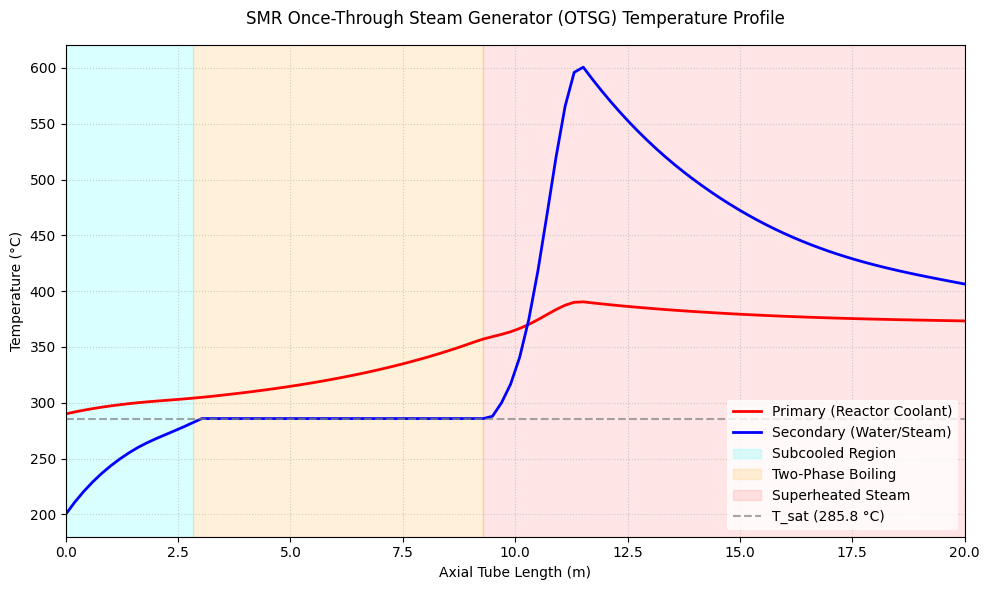

In [7]:
"""
OTSG Modeling Project: Once-Through Steam Generator Simulation
"""

import numpy as np
import CoolProp.CoolProp as CP
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict

# Parameters & Setup 

@dataclass
class OTSGParameters:
    """Main parameters for the Once-Through Steam Generator"""
    primary_pressure: float = 15.5          # MPa
    primary_inlet_temp: float = 315.0       # °C
    primary_outlet_temp: float = 290.0      # °C
    primary_mass_flow: float = 1000.0       # kg/s
    
    secondary_pressure: float = 7.0         # MPa
    secondary_inlet_temp: float = 200.0     # °C
    secondary_outlet_temp: float = 280.0    # °C
    secondary_mass_flow: float = 150.0      # kg/s
    
    tube_length: float = 20.0               # meters
    tube_inner_diameter: float = 0.015      # meters
    tube_outer_diameter: float = 0.019      # meters
    number_of_tubes: int = 1000
    tube_thermal_conductivity: float = 16.0 # W/(m·K) (Inconel 690)
    
    primary_h_coeff: float = 30000.0        # W/(m²·K)
    secondary_h_coeff: float = 25000.0      # W/(m²·K)


class CoolPropThermo:
    """Wrapper for CoolProp thermodynamic property calculations"""
    
    @staticmethod
    def get_enthalpy(pressure: float, temperature: float) -> float:
        """Calculate enthalpy using CoolProp (Returns: kJ/kg)"""
        try:
            p_pa = pressure * 1e6
            T_K = temperature + 273.15
            h = CP.PropsSI('H', 'T', T_K, 'P', p_pa, 'Water')
            return h / 1000.0
        except Exception:
            return 1000.0 + 2.0 * temperature
    
    @staticmethod
    def get_temperature(pressure: float, enthalpy: float) -> float:
        """Calculate temperature from pressure and enthalpy (Returns: °C)"""
        try:
            p_pa = pressure * 1e6
            h_J = enthalpy * 1000.0
            T_K = CP.PropsSI('T', 'H', h_J, 'P', p_pa, 'Water')
            return T_K - 273.15
        except Exception:
            return (enthalpy - 1000.0) / 2.0

    @staticmethod
    def get_saturation_temperature(pressure: float) -> float:
        """Get saturation temperature at given pressure (Returns: °C)"""
        try:
            p_pa = pressure * 1e6
            T_sat_K = CP.PropsSI('T', 'Q', 0.5, 'P', p_pa, 'Water')
            return T_sat_K - 273.15
        except Exception:
            if pressure < 22.064:
                return 100.0 + 20.0 * np.log(pressure)
            return 374.0


# Moving-Boundary Modeling

class MovingBoundaryOTSG:
    """Custom moving-boundary OTSG model using NumPy and SciPy"""
    
    def __init__(self, params: OTSGParameters):
        self.params = params
        self.thermo = CoolPropThermo()
        
        self.n_nodes = 100
        self.z = np.linspace(0, params.tube_length, self.n_nodes)
        
        self.t_primary = np.zeros(self.n_nodes)
        self.t_secondary = np.zeros(self.n_nodes)
        self.quality = np.zeros(self.n_nodes)
        self.boundary_locations = {}
        
    def calculate_heat_transfer_coefficient(self, phase: str = 'liquid') -> float:
        """Calculate heat transfer coefficient based on flow regime"""
        if phase == 'liquid':
            mu, k, Cp = 0.0003, 0.65, 4200
            Re = 100000
            Pr = mu * Cp / k
            Nu = 0.023 * (Re**0.8) * (Pr**0.4)
            return Nu * k / self.params.tube_inner_diameter
        elif phase == 'two-phase':
            return 50000.0
        else:
            mu, k, Cp = 0.00002, 0.035, 2100
            Re = 500000
            Pr = mu * Cp / k
            Nu = 0.023 * (Re**0.8) * (Pr**0.4)
            return Nu * k / self.params.tube_inner_diameter
    
    def solve_moving_boundary(self) -> Tuple[np.ndarray, np.ndarray, Dict]:
        """Solve transient profile along tube length via counter-flow ODE validation"""
        T_sat = self.thermo.get_saturation_temperature(self.params.secondary_pressure)
        h_in = self.thermo.get_enthalpy(self.params.secondary_pressure, self.params.secondary_inlet_temp)
        
        h_sat_l = CP.PropsSI('H', 'P', self.params.secondary_pressure * 1e6, 'Q', 0.0, 'Water') / 1000.0
        h_sat_v = CP.PropsSI('H', 'P', self.params.secondary_pressure * 1e6, 'Q', 1.0, 'Water') / 1000.0
        
        perimeter = np.pi * self.params.tube_inner_diameter * self.params.number_of_tubes
        
        def ode_system(z, y):
            h_sec, T_pri = y[0], y[1]
            T_sec = self.thermo.get_temperature(self.params.secondary_pressure, h_sec)
            
            if h_sec < h_sat_l:
                phase = 'liquid'
            elif h_sec < h_sat_v:
                phase = 'two-phase'
            else:
                phase = 'steam'
                
            h_conv_sec = self.calculate_heat_transfer_coefficient(phase)
            U = 1.0 / (1.0 / self.params.primary_h_coeff + 1.0 / h_conv_sec)
            
            q_prime = U * perimeter * (T_pri - T_sec)
            
            dh_sec_dz = q_prime / (self.params.secondary_mass_flow * 1000.0)
            dT_pri_dz = q_prime / (self.params.primary_mass_flow * 4180.0)
            return [dh_sec_dz, dT_pri_dz]

        guess_T_pri_out = self.params.primary_outlet_temp
        sol = solve_ivp(ode_system, [0, self.params.tube_length], [h_in, guess_T_pri_out], t_eval=self.z)
        
        h_sec_profile = sol.y[0]
        self.t_primary = sol.y[1]
        
        z_subcooled = self.z[h_sec_profile < h_sat_l]
        z_twophase = self.z[(h_sec_profile >= h_sat_l) & (h_sec_profile <= h_sat_v)]
        
        self.boundary_locations = {
            'boiling_start_z': z_subcooled[-1] if len(z_subcooled) > 0 else 0.0,
            'superheat_start_z': z_twophase[-1] if len(z_twophase) > 0 else self.params.tube_length
        }
        
        for i in range(self.n_nodes):
            self.t_secondary[i] = self.thermo.get_temperature(self.params.secondary_pressure, h_sec_profile[i])
            if h_sec_profile[i] < h_sat_l:
                self.quality[i] = 0.0
            elif h_sec_profile[i] > h_sat_v:
                self.quality[i] = 1.0
            else:
                self.quality[i] = (h_sec_profile[i] - h_sat_l) / (h_sat_v - h_sat_l)
                
        return self.t_primary, self.t_secondary, self.boundary_locations

    def plot_profiles(self):
        """Generate and show the thermal profile graph"""
        plt.figure(figsize=(10, 6))
        
        # Plot Temperature Profiles
        plt.plot(self.z, self.t_primary, 'r-', linewidth=2, label='Primary (Reactor Coolant)')
        plt.plot(self.z, self.t_secondary, 'b-', linewidth=2, label='Secondary (Water/Steam)')
        
        # Shade flow regime regions
        z_boil = self.boundary_locations['boiling_start_z']
        z_sh = self.boundary_locations['superheat_start_z']
        L = self.params.tube_length
        
        plt.axvspan(0, z_boil, color='cyan', alpha=0.15, label='Subcooled Region')
        plt.axvspan(z_boil, z_sh, color='orange', alpha=0.15, label='Two-Phase Boiling')
        plt.axvspan(z_sh, L, color='red', alpha=0.10, label='Superheated Steam')
        
        # Reference line for Saturation Temperature
        T_sat = self.thermo.get_saturation_temperature(self.params.secondary_pressure)
        plt.axhline(y=T_sat, color='gray', linestyle='--', alpha=0.7, label=f'T_sat ({T_sat:.1f} °C)')
        
        # Formatting
        plt.title('SMR Once-Through Steam Generator (OTSG) Temperature Profile', fontsize=12, pad=15)
        plt.xlabel('Axial Tube Length (m)', fontsize=10)
        plt.ylabel('Temperature (°C)', fontsize=10)
        plt.xlim(0, L)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
        plt.tight_layout()
        plt.show()


# --- Execution ---
if __name__ == "__main__":
    cfg = OTSGParameters()
    model = MovingBoundaryOTSG(cfg)
    t_p, t_s, bounds = model.solve_moving_boundary()
    
    print(f"Phase Boundaries found at:")
    print(f" - Boiling Starts: {bounds['boiling_start_z']:.2f} m")
    print(f" - Superheating Starts: {bounds['superheat_start_z']:.2f} m")
    
    # Render graph
    model.plot_profiles()


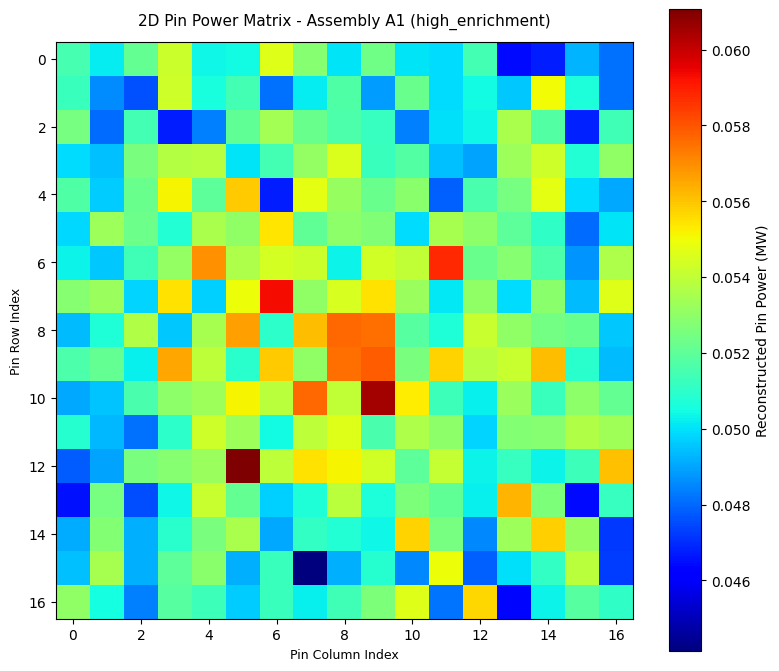

In [9]:
"""
PyReconstruct: Pin Power Reconstruction Module for NESTLE-like Core Simulators
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

# Data Structures 

@dataclass
class Pin:
    """Individual fuel pin with position and power data"""
    row: int
    col: int
    relative_power: float = 1.0
    form_factor: float = 1.0
    
@dataclass
class Assembly:
    """Fuel assembly containing pins and nodal data"""
    assembly_id: str
    assembly_type: str
    assembly_power: float  
    pins: List[Pin] = field(default_factory=list)
    pin_form_factors: Dict[int, float] = field(default_factory=dict)  
    
    @property
    def num_pins(self) -> int:
        return len(self.pins)
    
    def get_pin_power(self, pin_index: int) -> float:
        """Calculate pin power using the modulation method"""
        if pin_index in self.pin_form_factors:
            return self.assembly_power * self.pin_form_factors[pin_index]
        return self.assembly_power / self.num_pins if self.num_pins > 0 else 0.0
    
    def get_pin_powers(self) -> np.ndarray:
        """Get all pin powers for this assembly"""
        return np.array([self.get_pin_power(i) for i in range(self.num_pins)])

@dataclass
class Core:
    """Reactor core containing assemblies"""
    name: str
    assemblies: List[Assembly] = field(default_factory=list)
    assembly_grid: Dict[Tuple[int, int], Assembly] = field(default_factory=dict)
    pin_map: np.ndarray = field(default=None)  
    
    @property
    def num_assemblies(self) -> int:
        return len(self.assemblies)
    
    def add_assembly(self, assembly: Assembly, row: int, col: int):
        """Place assembly in core grid"""
        self.assemblies.append(assembly)
        self.assembly_grid[(row, col)] = assembly

# Pin Power Reconstruction Methods 

class PinPowerReconstructor:
    """Reconstructs pin powers from nodal diffusion results using the modulation method"""
    
    def __init__(self, core: Core):
        self.core = core
        
    def power_factorization(self) -> Core:
        """Implement power factorization method (Smith method)"""
        for assembly in self.core.assemblies:
            if assembly.pin_form_factors:
                pin_powers = assembly.get_pin_powers()
                total_power = np.sum(pin_powers)
                
                if total_power > 0:
                    pin_powers = (pin_powers / total_power) * assembly.assembly_power
                
                for i, pin in enumerate(assembly.pins):
                    pin.relative_power = pin_powers[i]
        
        return self.core

# --- Form Factor Generation ---

class FormFactorGenerator:
    """Generate pin form factors for different assembly types"""
    
    @staticmethod
    def generate_pwr_17x17_form_factors(assembly_type: str, seed: Optional[int] = None) -> Dict[int, float]:
        """Generate synthetic form factors for a 17x17 PWR assembly"""
        if seed is not None:
            np.random.seed(seed)
        
        num_pins = 17 * 17
        form_factors = {}
        center_row, center_col = 8, 8
        
        rows = np.arange(num_pins) // 17
        cols = np.arange(num_pins) % 17
        distances = np.sqrt((rows - center_row)**2 + (cols - center_col)**2)
        
        base_factors = 1.0 + 0.15 * np.exp(-distances / 5.0)
        variations = 0.05 * np.random.randn(num_pins)
        
        if assembly_type == "high_enrichment":
            base_factors *= 1.1
        elif assembly_type == "low_enrichment":
            base_factors *= 0.9
            
        final_factors = np.maximum(0.7, base_factors + variations)
        normalized_factors = final_factors / np.mean(final_factors)
        
        for i in range(num_pins):
            form_factors[i] = float(normalized_factors[i])
            
        return form_factors

#  Visualization Matrix Tool

class CoreVisualizer:
    """Generates 2D power distribution charts from assembly configurations"""
    
    @staticmethod
    def plot_assembly_power(assembly: Assembly):
        """Transform 1D array list into 17x17 grid matrix and render matrix plot"""
        grid_dim = int(np.sqrt(assembly.num_pins))
        if grid_dim * grid_dim != assembly.num_pins:
            raise ValueError("Assembly pin count must be a perfect square to form a grid.")
            
        # Convert pin attributes back into a 2D scalar map
        power_matrix = np.zeros((grid_dim, grid_dim))
        for pin in assembly.pins:
            power_matrix[pin.row, pin.col] = pin.relative_power
            
        plt.figure(figsize=(8, 7))
        im = plt.imshow(power_matrix, cmap='jet', interpolation='nearest')
        
        # Grid layout formatting
        plt.colorbar(im, label='Reconstructed Pin Power (MW)')
        plt.title(f"2D Pin Power Matrix - Assembly {assembly.assembly_id} ({assembly.assembly_type})", fontsize=11, pad=12)
        plt.xlabel("Pin Column Index", fontsize=9)
        plt.ylabel("Pin Row Index", fontsize=9)
        
        plt.xticks(np.arange(0, grid_dim, 2))
        plt.yticks(np.arange(0, grid_dim, 2))
        plt.grid(False)
        
        plt.tight_layout()
        plt.show()


# Execution
if __name__ == "__main__":
    my_core = Core(name="SMR Core Design Example")
    pwr_factors = FormFactorGenerator.generate_pwr_17x17_form_factors("high_enrichment", seed=42)
    
    test_assembly = Assembly(assembly_id="A1", assembly_type="high_enrichment", assembly_power=15.0, pin_form_factors=pwr_factors)
    for idx in range(17 * 17):
        test_assembly.pins.append(Pin(row=idx // 17, col=idx % 17))
        
    my_core.add_assembly(test_assembly, row=0, col=0)
    
    reconstructor = PinPowerReconstructor(my_core)
    updated_core = reconstructor.power_factorization()
    
    # Render the reconstructed assembly grid map
    CoreVisualizer.plot_assembly_power(updated_core.assemblies[0])
